In [10]:
%run 00setup.ipynb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Setup complete


In [11]:
import lightgbm as lgb
from lightgbm import LGBMRanker
df = load_df("features", DATA_DIR, fmt="parquet")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

In [12]:
target_col = "target"
true_ret_col = "target_raw"
meta_col = ["date", "ticker", "year", true_ret_col]

assert target_col in df.columns
assert true_ret_col in df.columns
assert "date" in df.columns and "ticker" in df.columns and "year" in df.columns

feature_cols = [c for c in df.columns if c not in meta_col + [target_col]]

print("Num features:", len(feature_cols))
print("Feature cols:", feature_cols)

Num features: 21
Feature cols: ['momentum_5', 'momentum_10', 'momentum_25', 'momentum_100', 'sma20_dev', 'rsi7', 'rsi14', 'volatility5', 'volatility20', 'volatility100', 'volatility20_ratio', 'volatility100_ratio', 'atr5', 'atr14', 'delta_atr10_atr100', 'log_vol', 'vol_std50', 'vol_slope', 'bb50_lower_slope', 'bb50_upper_slope', 'zsc_ret20']


In [13]:
years = sorted(df["year"].unique())
folds = []
for Y in years:
    train_years = list(range(Y-4, Y))
    if min(train_years) < years[0]:
        continue

    train_id = df["year"].isin(train_years)
    test_id  = df["year"].eq(Y)

    if train_id.sum() > 0 and test_id.sum() > 0:
        folds.append((train_id.values, test_id.values, (min(train_years), max(train_years), Y)))

print("Num folds:", len(folds), "| first:", folds[0][2], "| last:", folds[-1][2])

Num folds: 10 | first: (2012, 2015, np.int32(2016)) | last: (2021, 2024, np.int32(2025))


In [23]:
def make_group_sizes(df_slice: pd.DataFrame) -> np.ndarray:
    return df_slice.groupby("date").size().values

K_SELECT = 4

def topk_hit_rate(g: pd.DataFrame, k: int = K_SELECT) -> float:
    pred_top = set(g.nlargest(k, "y_pred")["ticker"])
    true_top = set(g.nlargest(k, "y_true_raw")["ticker"])
    return len(pred_top & true_top) / k

def cs_rank_ic(g: pd.DataFrame) -> float:
    x = g["y_pred"]
    y = g["y_true_raw"]
    m = x.notna() & y.notna()
    if m.sum() < 3:
        return np.nan
    return x[m].rank().corr(y[m].rank())

# Convert cross-sectional normalized target into integer relevance per date
def make_relevance_labels(s, q=5):
    r = s.rank(method="first")
    try:
        return pd.qcut(r, q=q, labels=False, duplicates="drop")
    except ValueError:
        return pd.Series(np.zeros(len(s), dtype=int), index=s.index)

df["rank_label"] = (
    df.groupby("date")[target_col]
      .transform(lambda s: make_relevance_labels(s, q=5))
      .astype(int)
)
rank_label_col = "rank_label"

oos_list = []
feat_gain = []

params = dict(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=4000,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.3,
    random_state=1,
    verbosity=-1,
)

for (tr_mask, te_mask, (y0, y1, yt)) in folds:
    df_tr_full = df.loc[tr_mask].sort_values(["date", "ticker"]).reset_index(drop=True)
    df_te = df.loc[te_mask].sort_values(["date", "ticker"]).reset_index(drop=True)

    unique_dates = df_tr_full["date"].drop_duplicates().sort_values().values
    if len(unique_dates) <= 80:
        print(f"Skip fold {y0}-{y1}->{yt}: not enough train dates ({len(unique_dates)})")
        continue

    cutoff_val_start = unique_dates[-60]
    df_tr = df_tr_full[df_tr_full["date"] < cutoff_val_start].reset_index(drop=True)
    df_va = df_tr_full[df_tr_full["date"] >= cutoff_val_start].reset_index(drop=True)

    X_tr, y_tr = df_tr[feature_cols], df_tr[rank_label_col]
    X_va, y_va = df_va[feature_cols], df_va[rank_label_col]
    X_te, y_te = df_te[feature_cols], df_te[rank_label_col]

    group_tr = make_group_sizes(df_tr)
    group_va = make_group_sizes(df_va)

    model = LGBMRanker(**params)

    model.fit(
        X_tr, y_tr,
        group=group_tr,
        eval_set=[(X_va, y_va)],
        eval_group=[group_va],
        eval_metric="ndcg",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
    )

    best_iter = model.best_iteration_ if model.best_iteration_ is not None else params["n_estimators"]

    evals = model.evals_result_
    ndcg2 = evals["valid_0"].get("ndcg@2", [np.nan])[best_iter - 1]
    ndcg3 = evals["valid_0"].get("ndcg@3", [np.nan])[best_iter - 1]
    ndcg5 = evals["valid_0"].get("ndcg@5", [np.nan])[best_iter - 1]
    print(f"Fold {y0}-{y1}->{yt} | best_iter={best_iter} | val NDCG@2={ndcg2:.4f} NDCG@3={ndcg3:.4f} NDCG@5={ndcg5:.4f}")

    y_pred = model.predict(X_te, num_iteration=best_iter)

    oos_list.append(pd.DataFrame({
        "date": df_te["date"].values,
        "ticker": df_te["ticker"].values,
        "y_true": y_te.values,
        "y_true_raw": df_te[true_ret_col].values,
        "y_pred": y_pred,
        "pred_rank": pd.Series(y_pred).rank(pct=True).values,
        "fold_year": yt
    }))

    feat_gain.append(
        pd.Series(
            model.booster_.feature_importance(importance_type="gain"),
            index=feature_cols
        )
    )

oos = (
    pd.concat(oos_list, ignore_index=True)
      .sort_values(["date", "ticker"])
      .reset_index(drop=True)
)
oos["pred_rank"] = oos.groupby("date")["y_pred"].rank(pct=True)

fi = (
    pd.concat(feat_gain, axis=1)
      .mean(axis=1)
      .sort_values(ascending=False)
      .rename("gain")
)

print("OOS rows:", len(oos), "| folds:", len(oos["fold_year"].unique()))
print("OOS year range:", oos["date"].dt.year.min(), "to", oos["date"].dt.year.max())

Fold 2012-2015->2016 | best_iter=1 | val NDCG@2=0.4006 NDCG@3=0.3697 NDCG@5=0.3938
Fold 2013-2016->2017 | best_iter=1 | val NDCG@2=0.4474 NDCG@3=0.4394 NDCG@5=0.4300
Fold 2014-2017->2018 | best_iter=3 | val NDCG@2=0.3579 NDCG@3=0.3826 NDCG@5=0.4282
Fold 2015-2018->2019 | best_iter=16 | val NDCG@2=0.4049 NDCG@3=0.4014 NDCG@5=0.4359
Fold 2016-2019->2020 | best_iter=21 | val NDCG@2=0.4790 NDCG@3=0.4745 NDCG@5=0.4656
Fold 2017-2020->2021 | best_iter=11 | val NDCG@2=0.4810 NDCG@3=0.4883 NDCG@5=0.4957
Fold 2018-2021->2022 | best_iter=28 | val NDCG@2=0.3758 NDCG@3=0.3813 NDCG@5=0.3974
Fold 2019-2022->2023 | best_iter=3 | val NDCG@2=0.3767 NDCG@3=0.3629 NDCG@5=0.3798
Fold 2020-2023->2024 | best_iter=9 | val NDCG@2=0.3927 NDCG@3=0.3741 NDCG@5=0.4177
Fold 2021-2024->2025 | best_iter=11 | val NDCG@2=0.4526 NDCG@3=0.4647 NDCG@5=0.4877
OOS rows: 50200 | folds: 10
OOS year range: 2016 to 2025


In [24]:
ric = oos.groupby("date").apply(cs_rank_ic, include_groups=False).dropna()

print(f"Rank-IC: mean={ric.mean():.3f} | median={ric.median():.3f} | std={ric.std():.3f} | n_days={len(ric)}")

hitk = oos.groupby("date").apply(lambda g: topk_hit_rate(g, k=K_SELECT), include_groups=False).dropna()
print(f"Top-{K_SELECT} hit-rate: mean={hitk.mean():.3f} | median={hitk.median():.3f}")

def topk_long_return(g, k=K_SELECT):
    return g.nlargest(k, "y_pred")["y_true_raw"].mean()

topk_ret = oos.groupby("date").apply(lambda g: topk_long_return(g, K_SELECT), include_groups=False)
univ_ret = oos.groupby("date")["y_true_raw"].mean()

ls = (topk_ret - univ_ret).sort_index()

holding_period = 3
mean_period_return = ls.mean()
annualized = (1 + mean_period_return) ** (252 / holding_period) - 1
print(f"Top-{K_SELECT} minus Universe (raw): mean {holding_period}D={mean_period_return:.6f} | annualized~={annualized:.3%}")

Rank-IC: mean=0.039 | median=0.039 | std=0.295 | n_days=2510
Top-4 hit-rate: mean=0.265 | median=0.250
Top-4 minus Universe (raw): mean 3D=0.000443 | annualized~=3.788%


In [31]:
# Cell 5A — Formal test of LGBM signal vs baseline (universe average)
import statsmodels.api as sm
from scipy import stats

# OOS excess return series:
# model-selected top-K basket minus passive universe average
excess = ls.dropna().copy()

print("Test series length:", len(excess))
print("Mean excess 5D return:", excess.mean())

# --- 1) Plain one-sample t-test against zero ---
t_stat, p_val = stats.ttest_1samp(excess, popmean=0.0, nan_policy="omit")
print(f"Plain t-test: t={t_stat:.3f}, p={p_val:.4f}")

# --- 2) Newey-West HAC t-test against zero ---
# Since returns can be autocorrelated, HAC is more defensible.
# With 5-day horizon, use a small lag such as 4.
X = np.ones(len(excess))
ols = sm.OLS(excess.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": 7})

alpha = ols.params[0]
t_hac = ols.tvalues[0]
p_hac = ols.pvalues[0]

print(f"Newey-West HAC test: alpha={alpha:.6f}, t={t_hac:.3f}, p={p_hac:.4f}")

# --- 3) Optional sign test as robustness check ---
n_pos = int((excess > 0).sum())
n_nonzero = int((excess != 0).sum())

if n_nonzero > 0:
    sign_res = stats.binomtest(n_pos, n_nonzero, p=0.5, alternative="greater")
    print(f"Sign test: positives={n_pos}/{n_nonzero}, p={sign_res.pvalue:.4f}")
else:
    print("Sign test skipped: no nonzero observations")

Test series length: 2510
Mean excess 5D return: 0.00044270439099702277
Plain t-test: t=2.810, p=0.0050
Newey-West HAC test: alpha=0.000443, t=1.988, p=0.0468
Sign test: positives=1329/2510, p=0.0017


In [26]:
# Cell 5B — Test whether model ranking beats random guessing
# universe size by date
n_by_date = oos.groupby("date")["ticker"].nunique()

# observed hits per date
hits_by_date = oos.groupby("date").apply(
    lambda g: len(
        set(g.nlargest(K_SELECT, "y_pred")["ticker"]) &
        set(g.nlargest(K_SELECT, "y_true_raw")["ticker"])
    ),
    include_groups=False
)

# total hits across all dates
total_hits = int(hits_by_date.sum())
total_trials = int((K_SELECT * len(hits_by_date)))

# null hit probability under random guessing
# if random top-K is chosen from N assets, expected hit probability per pick is K/N
p0_by_date = (K_SELECT / n_by_date).astype(float)
p0 = float(p0_by_date.mean())   # simple average null probability

print("Dates tested:", len(hits_by_date))
print("Average universe size:", n_by_date.mean())
print("K selected:", K_SELECT)
print("Observed avg hit rate:", total_hits / total_trials)
print("Random-guess hit rate benchmark:", p0)

# one-sided binomial test: is observed hit rate > random guessing?
res = stats.binomtest(total_hits, total_trials, p=p0, alternative="greater")
print(f"Binomial test vs random guessing: hits={total_hits}/{total_trials}, p={res.pvalue:.6f}")
obs_hit = total_hits / total_trials
lift = obs_hit / p0 if p0 > 0 else np.nan
print(f"Hit-rate lift vs random guessing: {lift:.2f}x")

Dates tested: 2510
Average universe size: 20.0
K selected: 4
Observed avg hit rate: 0.2647410358565737
Random-guess hit rate benchmark: 0.19999999999999998
Binomial test vs random guessing: hits=2658/10040, p=0.000000
Hit-rate lift vs random guessing: 1.32x


In [27]:
save_df(oos, "oos_predictions_ranker", DATA_DIR, fmt="parquet")
save_df(fi.reset_index().rename(columns={"index":"feature"}), "ranker_feature_importance", DATA_DIR, fmt="parquet")
print("Saved: oos_predictions_ranker.(parquet/csv) and ranker_feature_importance.(parquet/csv)")

Saved: oos_predictions_ranker.(parquet/csv) and ranker_feature_importance.(parquet/csv)


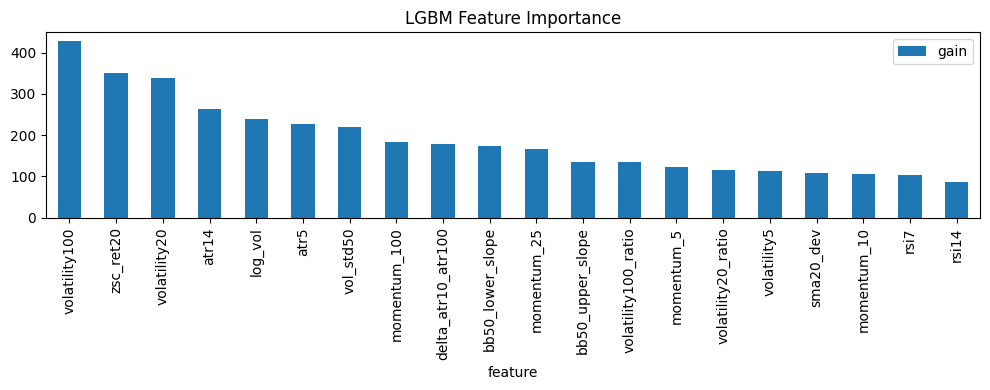

In [28]:
fi.reset_index().rename(columns={"index":"feature"}).head(20).plot(
    kind="bar", x="feature", y="gain", figsize=(10,4), title="LGBM Feature Importance"
)
plt.tight_layout()
plt.show()

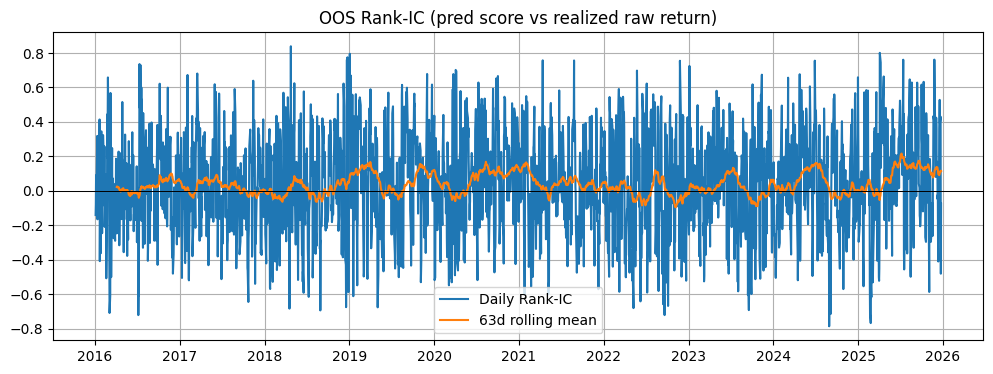

In [34]:
# Plot rolling Rank-IC
ric = oos.groupby("date", group_keys=False).apply(cs_rank_ic, include_groups=False).dropna()
ric_roll = ric.rolling(63).mean()  # ~3 months

plt.figure(figsize=(12,4))
plt.plot(ric.index, ric.values, label="Daily Rank-IC")
plt.plot(ric_roll.index, ric_roll.values, label="63d rolling mean")
plt.axhline(0, color="k", linewidth=0.7)
plt.title("OOS Rank-IC (pred score vs realized raw return)")
plt.grid(True)
plt.legend()
plt.show()

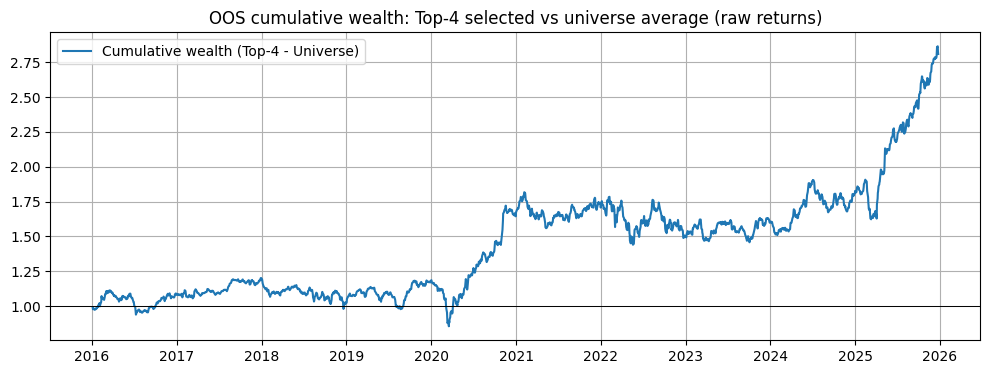

In [30]:
def topk_long_return(g, k):
    return g.nlargest(k, "y_pred")["y_true_raw"].mean()

topk_ret = oos.groupby("date", group_keys=False).apply(lambda g: topk_long_return(g, K_SELECT), include_groups=False)
univ_ret = oos.groupby("date")["y_true_raw"].mean()
spread = (topk_ret - univ_ret).sort_index()

plt.figure(figsize=(12,4))
plt.plot((1 + spread).cumprod().index, (1 + spread).cumprod().values, label=f"Cumulative wealth (Top-{K_SELECT} - Universe)")
plt.axhline(1.0, color="k", linewidth=0.7)
plt.title(f"OOS cumulative wealth: Top-{K_SELECT} selected vs universe average (raw returns)")
plt.grid(True)
plt.legend()
plt.show()